In [1]:
import torch.backends.cudnn as cudnn
cudnn.benchmark = True

from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils


from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt

import os 

from file_management import get_version_folder, save_config, load_config
from CityScapes import CityscapesDataset
from stylegan import StyleGenerator, Discriminator, Encoder


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [2]:
load_run = None

In [3]:
if load_run:
    config_path = os.path.join(load_run,'stylegan_config.yaml')
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/stylegan'
    index_folder = get_version_folder(root)
    config = load_config('stylegan_config.yaml')
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,'stylegan_config.yaml')
    save_config(config, config_target_path)




Config saved to cache/stylegan/32/stylegan_config.yaml


In [4]:
channels = config["models"]["channels"]

z_dim = config["models"]["z_dim"]



enc_block_depth = config["models"]["enc"]["block_depth"]
enc_residual = config["models"]["enc"]["residual"]

w_dim = config["models"]['rec_gen']["w_dim"]
mapping_network_depth = config["models"]['rec_gen']["mapping_network_depth"]
mapping_network_lr_mul  = config["models"]['rec_gen']["mapping_network_lr_mul"]
rec_gen_block_depth = config["models"]['rec_gen']["block_depth"]


disc_block_depth = config["models"]["disc"]["block_depth"]
disc_residual = config["models"]["disc"]["residual"]

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_vector_magnitude_loss_weight = config['training']['enc']['enc_vector_magnitude_loss_weight']


rec_gen_lr = config['training']['rec_gen']['rec_gen_lr']
style_mixing_prob = config['training']['rec_gen']['style_mixing_prob']
plp_lazy_regularisation  = config['training']['rec_gen']['plp_lazy_regularisation']
plp_decay = config['training']['rec_gen']['plp_decay']
plp_loss_weight = config['training']['rec_gen']['plp_loss_weight']


disc_lr = config['training']['disc']['disc_lr']
r1_loss_weight = config['training']['disc']['r1_loss_weight']
r1_lazy_regularisation = config['training']['disc']['r1_lazy_regularisation']


save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

Text(0.5, 1.0, 'Fake')

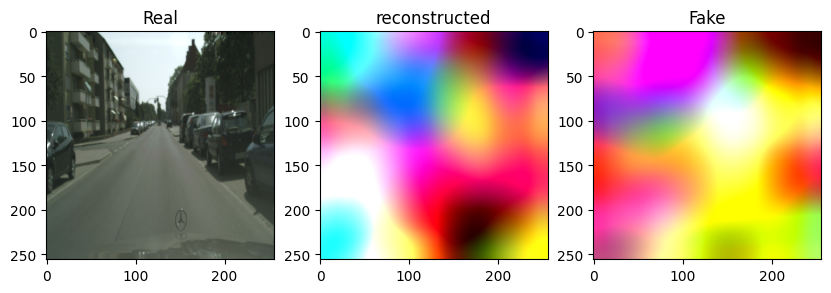

In [5]:


enc = Encoder(channels=channels,
              z_dim=z_dim,
              block_depth=enc_block_depth,
              residual=enc_residual,
              img_channels=3).to(device)

rec_gen = StyleGenerator(z_dim=z_dim,
                     w_dim=w_dim,
                     mapping_network_depth=mapping_network_depth,
                     mapping_network_lr_mul=0.01,
                     channels=channels,
                     block_depth=rec_gen_block_depth,
                     img_channels=3).to(device)


disc = Discriminator(channels=channels,
                     block_depth=disc_block_depth,
                     residual=disc_residual,
                     img_channels=3).to(device)



enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
rec_gen_optim = Adam(rec_gen.parameters(), lr=rec_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0
z = torch.randn(batch_size, z_dim).to(device)
fake = rec_gen(z)
fake.shape




real,_ = next(iter(train_loader))
real = real.to(device)
encoded_vector = enc(real)
reconstructed_real = rec_gen(encoded_vector)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


reconstructed_real=  scale_for_display(reconstructed_real)
ax[1].imshow(reconstructed_real[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('reconstructed')

fake =scale_for_display(fake)
ax[2].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[2].set_title('Fake')



In [6]:
def compute_r1_penalty(real, disc_real):
    # Compute R1 gradient penalty
    grad_real = torch.autograd.grad(
        outputs=disc_real.sum(), 
        inputs=real, 
        create_graph=True
    )[0]
    r1_penalty = grad_real.square().sum(dim=[1, 2, 3]).mean()
    return r1_penalty

In [7]:

import torch
import math

def compute_path_length_penalty(fake_images, w, moving_average_a, decay):
    """
    Calculates the StyleGAN2 Path Length Penalty.
    
    Args:
        fake_images: The reconstructed images from G(w), shape [batch_size, C, H, W]
        w: The intermediate latent vectors, shape [batch_size, w_dim]
        moving_average_a: A tensor containing a single scalar, tracking the EMA of path lengths
        decay: Decay rate for the exponential moving average (0.99 in the paper)
        
    Returns:
        penalty: The computed scalar loss
        moving_average_a: The updated running average
    """
    
    # 1. Generate the random noise image 'y' ~ N(0, I)
    # We scale it by 1 / sqrt(H * W) so the magnitude of the penalty 
    # doesn't blow up as your image resolution gets larger.
    pixel_count = fake_images.shape[2] * fake_images.shape[3]
    noise = torch.randn_like(fake_images) / math.sqrt(pixel_count)
    
    # 2. The JVP Trick: Collapse the multi-output function into a single scalar
    jvp_scalar = (fake_images * noise).sum()
    
    # 3. Calculate the Jacobian-Vector Product ( J^T_w * y )
    # create_graph=True is required so we can backpropagate THROUGH this gradient
    grad, = torch.autograd.grad(
        outputs=jvp_scalar,
        inputs=w,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )
    
    # 4. Calculate the L2 norm (magnitude) of the gradients: || J^T_w * y ||_2
    # grad is shape [batch_size, w_dim]. We square, sum across the w_dim, and take the square root.
    path_lengths = torch.sqrt(grad.pow(2).sum(dim=1))
    
    # 5. Update the running average 'a'
    # We use .detach() because 'a' is just a tracker; we don't want to optimize it.
    with torch.no_grad():
        if moving_average_a.item() == 0.0:  # Initialize on the very first training step
            moving_average_a = path_lengths.mean().detach()
        else:
            moving_average_a = moving_average_a * decay + path_lengths.mean().detach() * (1 - decay)
            
    # 6. Calculate the final squared penalty: (|| J^T_w * y ||_2 - a)^2
    # The .mean() serves as the Expectation (E) over the batch.
    penalty = (path_lengths - moving_average_a).pow(2).mean()
    
    return penalty, moving_average_a


In [ ]:
epochs = 100

for epoch in range(3,epochs):
    loop = tqdm(train_loader)
    loop.set_description(f"Epoch {epoch}/{epochs}")
    for i, (real,_) in enumerate(loop):

        current_batch_size = real.shape[0]
        real = real.to(device)
        z_noise = torch.randn(current_batch_size,z_dim).to(device)

        disc_optim.zero_grad()
    

        with torch.no_grad():
            fake =rec_gen(z_noise,style_mixing_prob=style_mixing_prob)
            fake = fake.detach()
        disc_fake = disc(fake)
        disc_fake_loss = F.softplus(disc_fake).mean()

        real.requires_grad_(True)
        disc_real = disc(real)

        disc_real_loss = F.softplus(-disc_real).mean()

        with torch.no_grad():
            encoded_vector = enc(real)
            reconstructed = rec_gen(encoded_vector)
        disc_reconstructed_real = disc(reconstructed)
        disc_reconstructed_loss = F.softplus(-disc_reconstructed_real).mean()
        
        disc_adv_loss = (disc_real_loss + disc_fake_loss + disc_reconstructed_loss)/3

       
        disc_loss = disc_adv_loss 
        disc_loss.backward()
        disc_optim.step()

        if i % r1_lazy_regularisation == 0:
            disc_optim.zero_grad()
            
            # We need a fresh forward pass on real images for the penalty
            real.requires_grad_(True)
            disc_real_reg = disc(real)
            
            r1_penalty = r1_loss_weight * compute_r1_penalty(real, disc_real_reg)
            
            r1_loss = r1_penalty  * r1_lazy_regularisation
            
            r1_loss.backward()
            disc_optim.step()

        enc_optim.zero_grad()
        rec_gen_optim.zero_grad()

        z_noise = torch.randn(current_batch_size,z_dim).to(device)
        fake = rec_gen(z_noise,style_mixing_prob=style_mixing_prob)
        gen_fake = disc(fake)
        gen_adv_loss = F.softplus(-gen_fake).mean()

        gen_loss = gen_adv_loss

        encoded_vector = enc(real)
        reconstructed = rec_gen(encoded_vector)
        disc_reconstruted = disc(reconstructed)

        enc_adv_loss = F.softplus(-disc_reconstruted).mean()
        enc_reconstruction_loss = enc_reconstruction_loss_weight * F.l1_loss(reconstructed, real)
        enc_vector_magnitude_loss = enc_vector_magnitude_loss_weight *  torch.mean(encoded_vector ** 2)
        enc_loss = enc_adv_loss + enc_reconstruction_loss + enc_vector_magnitude_loss

        enc_gen_loss = gen_loss + enc_loss
        enc_gen_loss.backward()
        enc_optim.step()
        rec_gen_optim.step()



        if i % plp_lazy_regularisation == 0:
            rec_gen_optim.zero_grad()
            
            z_plp = torch.randn(current_batch_size, z_dim).to(device)
            fake_plp, w_plp = rec_gen(z_plp, return_w=True)
            
            # Pass the generator's internal buffer to the function
            plp, updated_mean = compute_path_length_penalty(fake_plp, w_plp, rec_gen.pl_mean,plp_decay)
            
            # Update the generator's buffer
            rec_gen.pl_mean.copy_(updated_mean)
            
            loss_plp = plp * plp_loss_weight * plp_lazy_regularisation
            loss_plp.backward()
            rec_gen_optim.step()


        # Discriminator losses
        writer.add_scalar('Discriminator_Losses/Adversarial', disc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Discriminator_Losses/R1_Penalty', r1_penalty.item() if i % r1_lazy_regularisation == 0 else 0.0, tensorboard_step)

        # Encoder losses
        writer.add_scalar('Encoder_Losses/Adversarial', enc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Reconstruction', enc_reconstruction_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Vector_Magnitude', enc_vector_magnitude_loss.item(), tensorboard_step)

        # Generator losses
        writer.add_scalar('Generator_Losses/Adversarial', gen_adv_loss.item(), tensorboard_step)
        
        tensorboard_step += 1
        loop.set_postfix(loss_disc=disc_loss.item(),loss_gen=gen_loss.item(),enc_loss=enc_loss.item())
        if (i+1) % save_itter == 0:
            torch.save(rec_gen.state_dict(), gen_path)
            torch.save(disc.state_dict(),disc_path)

            epoch_root= 'epoch_{}'.format(epoch)
            os.makedirs(os.path.join(samples_path,epoch_root),exist_ok=True)
        
            with torch.no_grad():
                noise = torch.randn(current_batch_size, z_dim).to(device)
                fake = rec_gen(noise) 


            encoded_vector = enc(real)
            reconstructed = rec_gen(encoded_vector)


            fake =scale_for_display(fake)
            reconstructed =scale_for_display(reconstructed)
            real =scale_for_display(real)

            imgs_to_plot = torch.cat([
                real[:4],           # Top row: Real
                reconstructed[:4],  # Middle row: Reconstructed
                fake[:4]       # Bottom row: Fake
            ], dim=0)
            
           
            # Create a grid natively on the tensσors
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            
            # 1. Save to disk (replaces plt.savefig)
            img_path = os.path.join(samples_path, epoch_root, f'{i}.png')
            vutils.save_image(grid, img_path)
            
    


Epoch 3/100:   8%|▊         | 192/2500 [01:04<09:24,  4.09it/s, enc_loss=0.413, loss_disc=0.0144, loss_gen=4.25]   

Text(0.5, 1.0, 'Fake')

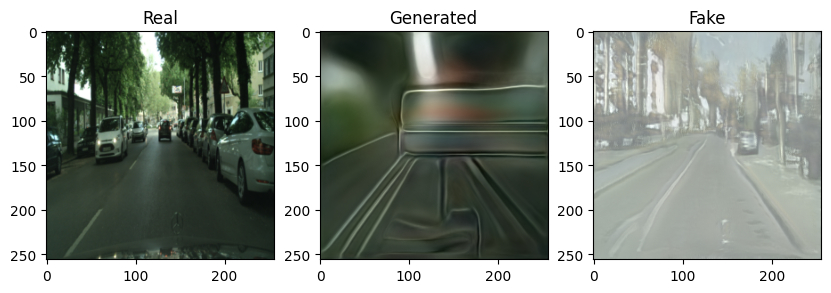

In [ ]:


real,_ = next(iter(train_loader))
real = real.to(device)
encoded_vector = enc(real)
reconstructed_real = rec_gen(encoded_vector)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


reconstructed_real=  scale_for_display(reconstructed_real)
ax[1].imshow(reconstructed_real[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('reconstructed')

fake =scale_for_display(fake)
ax[2].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[2].set_title('Fake')